# Results

This notebook plots the data generated by the `mlp.py`, `logistic_regression.py` and `gnn.py` modules. The logs live under `logs/<model>/<encoder>.log` (a flat layout — one file per model/encoder pair). For each model (MLP, Logistic Regression, GraphSAGE) we compare the four text encoders: BOW, TF-IDF, SBERT, Qwen3-Embedding-0.6B.

- **MLP / GraphSAGE**: per-epoch training & validation loss curves, validation accuracy, and final test scores.
- **Logistic Regression**: final test accuracy.


In [50]:
import os
import re

import matplotlib.pyplot as plt

LOGS_DIR = "logs"

ENCODER_ORDER = ["bow", "tfidf", "sbert", "qwen06B"]
ENCODER_LABEL = {
    "bow": "BOW",
    "tfidf": "TF-IDF",
    "sbert": "SBERT",
    "qwen06B": "Qwen3-Emb-0.6B",
}
ENCODER_COLOR = {
    "bow": "#1f77b4",
    "tfidf": "#ff7f0e",
    "sbert": "#2ca02c",
    "qwen06B": "#d62728",
}

MODEL_LABEL = {
    "mlp": "MLP",
    "lr": "Logistic Regression",
    "sage": "GraphSAGE",
}

EPOCH_RE = re.compile(
    r"\[EPOCH\s+(\d+)\]\s+train_loss=([0-9.]+)(?:\s+val_loss=([0-9.]+))?"
)
SCORE_RE = re.compile(
    r"Accuracy:\s*([0-9.]+).*?Macro F1:\s*([0-9.]+).*?Weighted F1:\s*([0-9.]+)",
    re.DOTALL,
)


def parse_epoch_log(path):
    epochs, train, val = [], [], []
    with open(path) as f:
        for line in f:
            m = EPOCH_RE.search(line)
            if m:
                epochs.append(int(m.group(1)))
                train.append(float(m.group(2)))
                val.append(float(m.group(3)) if m.group(3) else None)
    return epochs, train, val


def parse_scores(path):
    with open(path) as f:
        text = f.read()
    m = SCORE_RE.search(text)
    if not m:
        return None
    return {
        "accuracy": float(m.group(1)),
        "macro_f1": float(m.group(2)),
        "weighted_f1": float(m.group(3)),
    }


def collect(model):
    """Return {encoder: path} for the given model."""
    base = os.path.join(LOGS_DIR, model)
    out = {}
    if not os.path.isdir(base):
        return out
    for enc in ENCODER_ORDER:
        p = os.path.join(base, f"{enc}.log")
        if os.path.exists(p):
            out[enc] = p
    return out


mlp_runs = collect("mlp")
lr_runs = collect("lr")
sage_runs = collect("sage")
print("MLP encoders :", list(mlp_runs.keys()))
print("LR encoders  :", list(lr_runs.keys()))
print("SAGE encoders:", list(sage_runs.keys()))


MLP encoders : ['bow', 'tfidf', 'sbert', 'qwen06B']
LR encoders  : ['bow', 'tfidf', 'sbert', 'qwen06B']
SAGE encoders: ['bow', 'tfidf', 'sbert', 'qwen06B']


## MLP & GraphSAGE — training loss curves

One subplot per model. Solid lines: train loss. Dashed lines: validation loss (when logged).


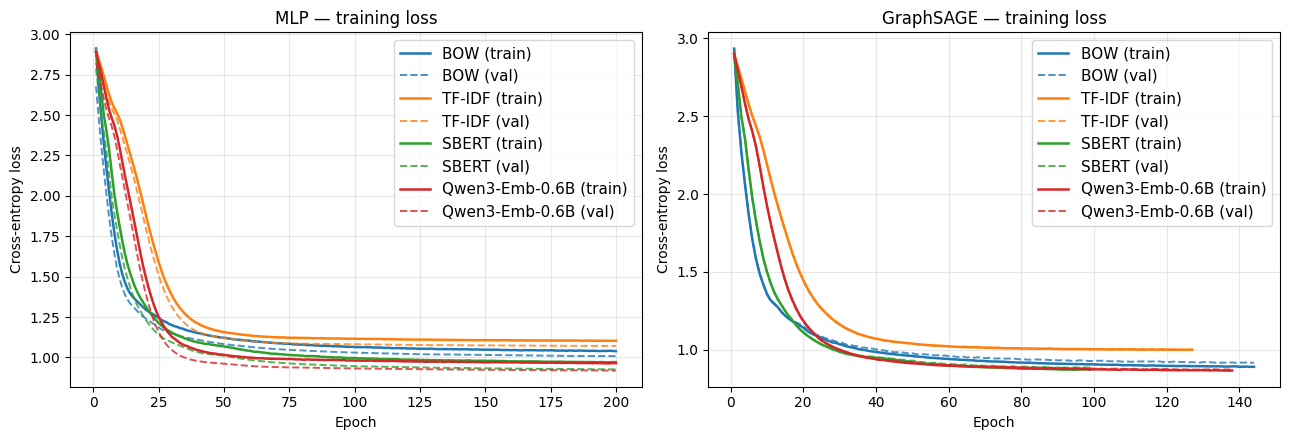

In [51]:
def plot_loss_curves(model_runs):
    """model_runs: list of (model_key, {encoder: path})."""
    model_runs = [(m, r) for m, r in model_runs if r]
    if not model_runs:
        print("No epoch logs found.")
        return
    ncols = len(model_runs)
    fig, axes = plt.subplots(1, ncols, figsize=(6.5 * ncols, 4.5), squeeze=False)
    axes = axes[0]
    for ax, (model, encoders) in zip(axes, model_runs):
        for enc in ENCODER_ORDER:
            if enc not in encoders:
                continue
            epochs, train, val = parse_epoch_log(encoders[enc])
            if not epochs:
                continue
            color = ENCODER_COLOR[enc]
            label = ENCODER_LABEL[enc]
            ax.plot(epochs, train, color=color, label=f"{label} (train)", linewidth=1.8)
            val_clean = [(e, v) for e, v in zip(epochs, val) if v is not None]
            if val_clean:
                ev, vv = zip(*val_clean)
                ax.plot(ev, vv, color=color, linestyle="--",
                        label=f"{label} (val)", linewidth=1.4, alpha=0.8)
        ax.set_title(f"{MODEL_LABEL[model]} — training loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Cross-entropy loss")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=11, loc="upper right")
    fig.tight_layout()
    plt.show()


plot_loss_curves([("mlp", mlp_runs), ("sage", sage_runs)])


## MLP & GraphSAGE — validation accuracy curves

One subplot per model. Per-epoch `val_acc` parsed from the training logs.


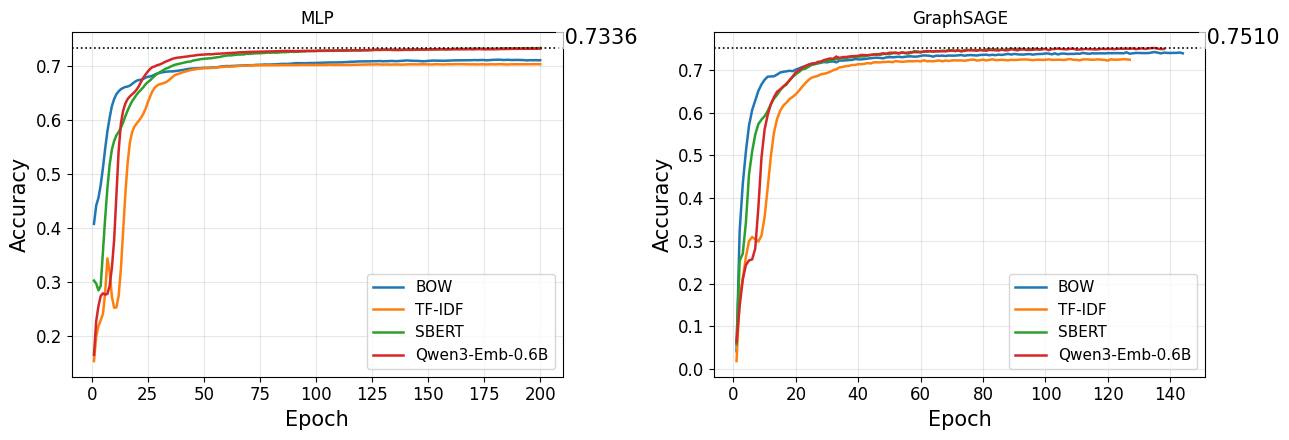

In [ ]:
VAL_ACC_RE = re.compile(
    r"\[EPOCH\s+(\d+)\].*?val_acc=([0-9.]+)"
)


def parse_val_acc(path):
    epochs, acc = [], []
    with open(path) as f:
        for line in f:
            m = VAL_ACC_RE.search(line)
            if m:
                epochs.append(int(m.group(1)))
                acc.append(float(m.group(2)))
    return epochs, acc


def plot_val_accuracy(model_runs):
    model_runs = [(m, r) for m, r in model_runs if r]
    if not model_runs:
        print("No epoch logs found.")
        return
    ncols = len(model_runs)
    fig, axes = plt.subplots(1, ncols, figsize=(6.5 * ncols, 4.5), squeeze=False)
    axes = axes[0]
    for ax, (model, encoders) in zip(axes, model_runs):
        any_plotted = False
        best_overall = None
        for enc in ENCODER_ORDER:
            if enc not in encoders:
                continue
            epochs, acc = parse_val_acc(encoders[enc])
            if not epochs:
                continue
            ax.plot(epochs, acc, color=ENCODER_COLOR[enc],
                    label=ENCODER_LABEL[enc], linewidth=1.8)
            any_plotted = True
            enc_best = max(acc)
            if best_overall is None or enc_best > best_overall:
                best_overall = enc_best
        if best_overall is not None:
            ax.axhline(best_overall, color="black", linestyle=":", linewidth=1.2)
            ax.text(0.99, best_overall, f" {best_overall:.4f}",
                    transform=ax.get_yaxis_transform(),
                    ha="left", va="bottom", fontsize=15,
                    color="black",
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1))
        ax.set_title(f"{MODEL_LABEL[model]}")
        ax.set_xlabel("Epoch", fontsize=15)
        ax.set_ylabel("Accuracy", fontsize=15)
        for tick in ax.get_yticklabels():
            tick.set_fontsize(12)
        for tick in ax.get_xticklabels():
            tick.set_fontsize(12)
        ax.grid(True, alpha=0.3)
        if any_plotted:
            ax.legend(fontsize=11, loc="lower right")
    fig.tight_layout()
    plt.show()


plot_val_accuracy([("mlp", mlp_runs), ("sage", sage_runs)])


## Final test accuracy per encoder

One subplot per model (Logistic Regression, MLP, GraphSAGE), comparing the four encoders.


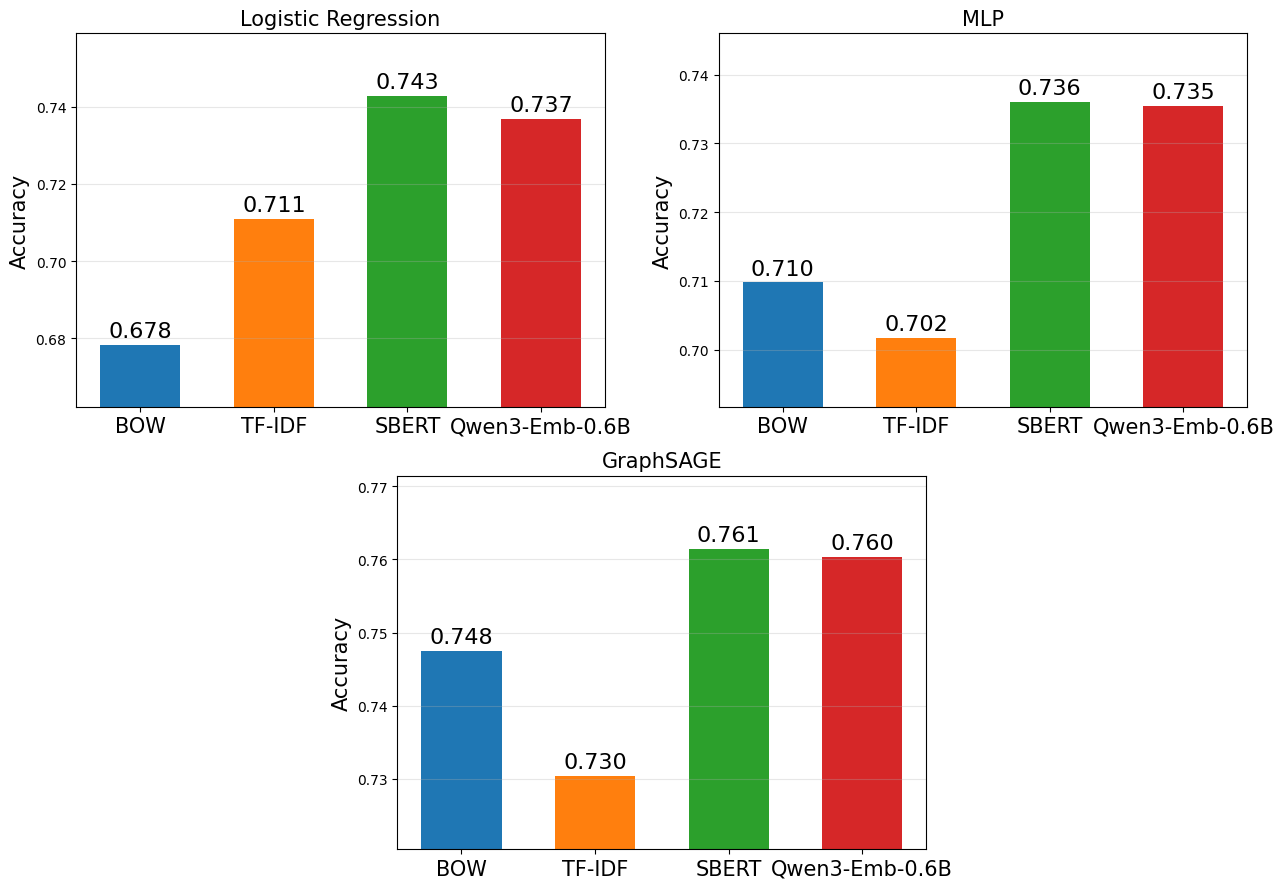

In [53]:
import numpy as np


def _grid_axes(fig, n, ncols=2):
    """Return a list of n axes; if the last row has a single plot, center it."""
    nrows = (n + ncols - 1) // ncols
    gs = fig.add_gridspec(nrows, ncols * 2)
    axes = []
    for i in range(n):
        row = i // ncols
        col_in_row = i % ncols
        is_last_row = row == nrows - 1
        items_in_last_row = n - ncols * (nrows - 1)
        if is_last_row and items_in_last_row < ncols:
            # center the lone plot(s) on the last row
            total_span = ncols * 2
            span = 2
            start = (total_span - items_in_last_row * span) // 2 + col_in_row * span
            axes.append(fig.add_subplot(gs[row, start:start + span]))
        else:
            start = col_in_row * 2
            axes.append(fig.add_subplot(gs[row, start:start + 2]))
    return axes


def plot_final_scores(model_runs):
    model_runs = [(m, r) for m, r in model_runs if r]
    if not model_runs:
        print("No logs found.")
        return
    n = len(model_runs)
    ncols = 2 if n > 1 else 1
    nrows = (n + ncols - 1) // ncols
    fig = plt.figure(figsize=(6.5 * ncols, 4.5 * nrows))
    axes = _grid_axes(fig, n, ncols=ncols)
    for ax, (model, encoders) in zip(axes, model_runs):
        encs_present = [e for e in ENCODER_ORDER if e in encoders]
        scores = {e: parse_scores(encoders[e]) for e in encs_present}
        encs_present = [e for e in encs_present if scores[e] is not None]
        if not encs_present:
            ax.set_title(f"{MODEL_LABEL[model]} — no scores")
            continue
        x = np.arange(len(encs_present))
        vals = [scores[e]["accuracy"] for e in encs_present]
        colors = [ENCODER_COLOR[e] for e in encs_present]
        vmin, vmax = min(vals), max(vals)
        pad = max(0.01, (vmax - vmin) * 0.25)
        y_lo = max(0.0, vmin - pad)
        y_hi = min(1.0, vmax + pad)
        ax.bar(x, vals, 0.6, color=colors)
        for xi, v in zip(x, vals):
            ax.text(xi, v + (y_hi - y_lo) * 0.01, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=16)
        ax.set_xticks(x)
        ax.set_xticklabels([ENCODER_LABEL[e] for e in encs_present], fontsize=15)
        ax.set_title(f"{MODEL_LABEL[model]}", fontsize=15)
        ax.set_ylabel("Accuracy", fontsize=15)
        ax.set_ylim(y_lo, y_hi)
        ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


plot_final_scores([("lr", lr_runs), ("mlp", mlp_runs), ("sage", sage_runs)])


## Training time per encoder

Total wall-clock training time per encoder, parsed from the `[TRAINING] Completed in Xs` line of each log. One subplot per model.


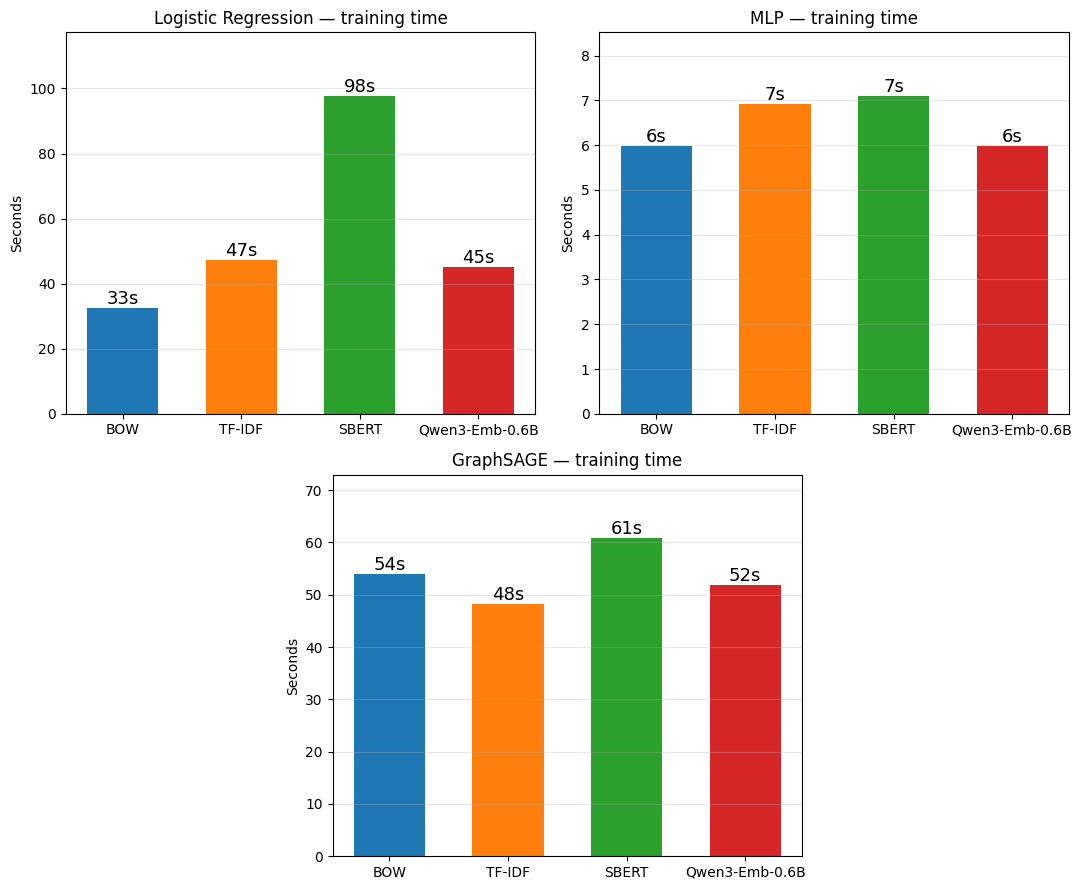

In [54]:
TRAIN_TIME_RE = re.compile(r"\[TRAINING\]\s+Completed in\s+([0-9.]+)s")


def parse_train_time(path):
    with open(path) as f:
        for line in f:
            m = TRAIN_TIME_RE.search(line)
            if m:
                return float(m.group(1))
    return None


def plot_train_times(model_runs):
    model_runs = [(m, r) for m, r in model_runs if r]
    if not model_runs:
        print("No logs found.")
        return
    n = len(model_runs)
    ncols = 2 if n > 1 else 1
    nrows = (n + ncols - 1) // ncols
    fig = plt.figure(figsize=(5.5 * ncols, 4.5 * nrows))
    axes = _grid_axes(fig, n, ncols=ncols)
    for ax, (model, encoders) in zip(axes, model_runs):
        encs_present = [e for e in ENCODER_ORDER if e in encoders]
        vals = [parse_train_time(encoders[e]) or 0.0 for e in encs_present]
        x = np.arange(len(encs_present))
        colors = [ENCODER_COLOR[e] for e in encs_present]
        bars = ax.bar(x, vals, 0.6, color=colors)
        for b, v in zip(bars, vals):
            if v > 0:
                ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.0f}s",
                        ha="center", va="bottom", fontsize=13)
        ax.set_xticks(x)
        ax.set_xticklabels([ENCODER_LABEL[e] for e in encs_present])
        ax.set_title(f"{MODEL_LABEL[model]} — training time")
        ax.set_ylabel("Seconds")
        ax.grid(True, axis="y", alpha=0.3)
        if vals and max(vals) > 0:
            ax.set_ylim(0, max(vals) * 1.2)
    fig.tight_layout()
    plt.show()


plot_train_times([("lr", lr_runs), ("mlp", mlp_runs), ("sage", sage_runs)])


## Encoding time per encoder

Wall-clock time spent encoding the corpus, parsed from the `[ENCODE] <name> done in Xs` line. The encoding step is run once per encoder; the time is looked up across all model log folders, so a single bar per encoder is reported.


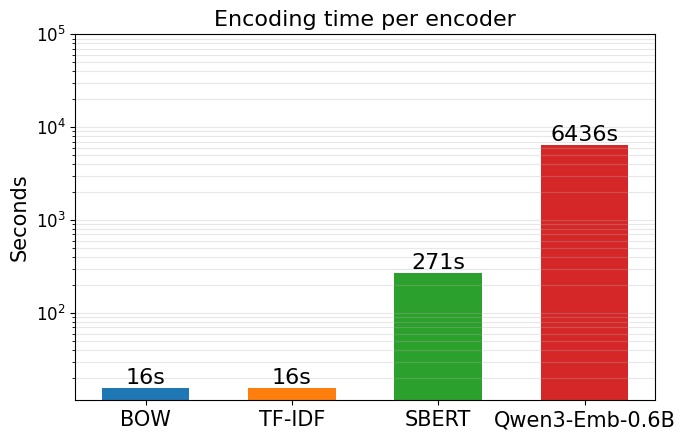

In [55]:
ENCODE_TIME_RE = re.compile(r"\[ENCODE\]\s+\S+\s+done in\s+([0-9.]+)s")


def parse_encode_time(path):
    with open(path) as f:
        for line in f:
            m = ENCODE_TIME_RE.search(line)
            if m:
                return float(m.group(1))
    return None


def encode_time_lookup(enc, all_runs):
    """Find the encoding time for `enc` in any of the given model run dicts."""
    for runs in all_runs:
        path = runs.get(enc)
        if path is None:
            continue
        t = parse_encode_time(path)
        if t is not None:
            return t
    return None


def plot_encoding_times(all_runs):
    encs_present = [e for e in ENCODER_ORDER
                    if any(e in r for r in all_runs)]
    vals = [encode_time_lookup(e, all_runs) or 0.0 for e in encs_present]
    if not any(v > 0 for v in vals):
        print("No encoding times found.")
        return
    fig, ax = plt.subplots(figsize=(7, 4.5))
    x = np.arange(len(encs_present))
    colors = [ENCODER_COLOR[e] for e in encs_present]
    bars = ax.bar(x, vals, 0.6, color=colors)
    for b, v in zip(bars, vals):
        if v > 0:
            ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.0f}s",
                    ha="center", va="bottom", fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels([ENCODER_LABEL[e] for e in encs_present], fontsize=15)
    ax.set_title("Encoding time per encoder", fontsize=16)
    ax.set_ylabel("Seconds", fontsize=15)
    ax.set_yscale("log")
    ax.set_ylim(top=1e5)
    for tick in ax.get_yticklabels():
        tick.set_fontsize(12)
    ax.grid(True, axis="y", which="both", alpha=0.3)
    fig.tight_layout()
    plt.show()


plot_encoding_times([mlp_runs, lr_runs, sage_runs])
